In [1]:
import geopandas as gpd
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

### Bar Plot

In [2]:
 # Folder containing the files
covers_path = "./data/cover/coverl2" 

# List all files in the folder
files = [f for f in os.listdir(covers_path)]

lc = {}

for file in files:
    path = os.path.join(covers_path, file)
    gdf = gpd.read_file(path)
    lc[file] = gdf

In [3]:
for filename, data in lc.items():
    if "2000" in filename:
        data['year'] = 2000
    elif "2010" in filename:
        data['year'] = 2010
    elif "2018" in filename:
        data['year'] = 2018

In [4]:
# Merge by department
ara=pd.concat([lc['ara_cover2000l2.gpkg'], lc['ara_cover2010l2.gpkg'], lc['ara_cover2018l2.gpkg']], ignore_index=True)
casa=pd.concat([lc['casa_cover2000l2.gpkg'], lc['casa_cover2010l2.gpkg'], lc['casa_cover2018l2.gpkg']], ignore_index=True)
meta=pd.concat([lc['meta_cover2000l2.gpkg'], lc['meta_cover2010l2.gpkg'], lc['meta_cover2018l2.gpkg']], ignore_index=True)

In [ ]:
# Calculate area in square kilometers and aggregate by 'level2'
ara["Area"] = ara.geometry.area / 1e6
casa["Area"] = casa.geometry.area / 1e6
meta["Area"] = meta.geometry.area / 1e6

In [ ]:
# Remove '9.9 Unknown' class related to clouds presence
ara_noclouds = ara[ara["level2"] != "9.9 Unknown"]
casa_noclouds = casa[casa["level2"] != "9.9 Unknown"]
meta_noclouds = meta[meta["level2"] != "9.9 Unknown"]

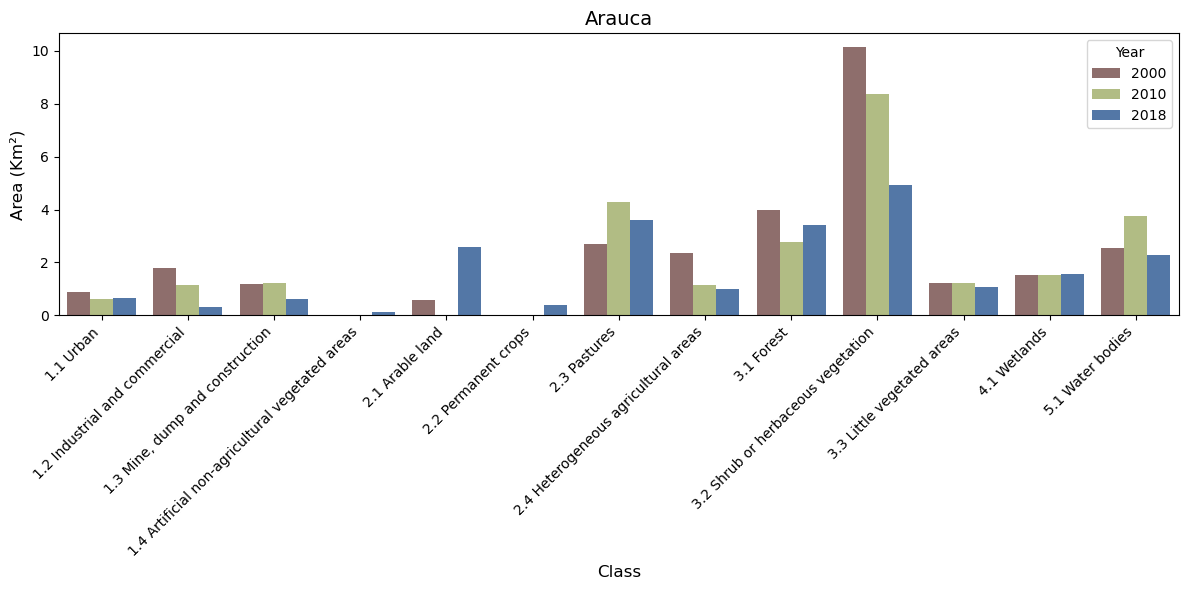

In [13]:
# Arauca plot
plt.figure(figsize=(12, 6))
sns.barplot(
    data=ara_noclouds ,
    x="level2",
    y="Area",
    hue="year",
    palette=["#946966", "#b6c57b", "#4575b4"],
    errorbar=None,
    order=sorted(ara_noclouds["level2"].unique())
)

# Style the plot
plt.title("Arauca", fontsize=14)
plt.xlabel("Class", fontsize=12)
plt.ylabel("Area (Km²)", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title="Year")
plt.tight_layout()
plt.show()

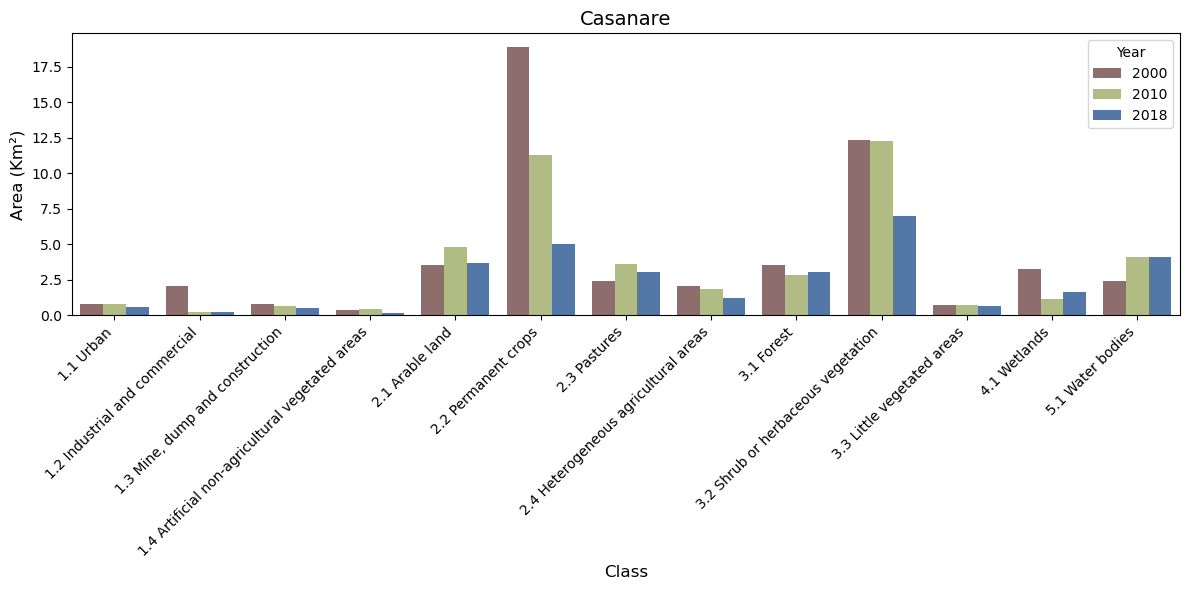

In [14]:
# Casanare plot
plt.figure(figsize=(12, 6))
sns.barplot(
    data=casa_noclouds,
    x="level2",
    y="Area",
    hue="year",
    palette=["#946966", "#b6c57b", "#4575b4"],
    errorbar=None,
    order=sorted(casa_noclouds["level2"].unique())
)

# Style the plot
plt.title("Casanare", fontsize=14)
plt.xlabel("Class", fontsize=12)
plt.ylabel("Area (Km²)", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title="Year")
plt.tight_layout()
plt.show()

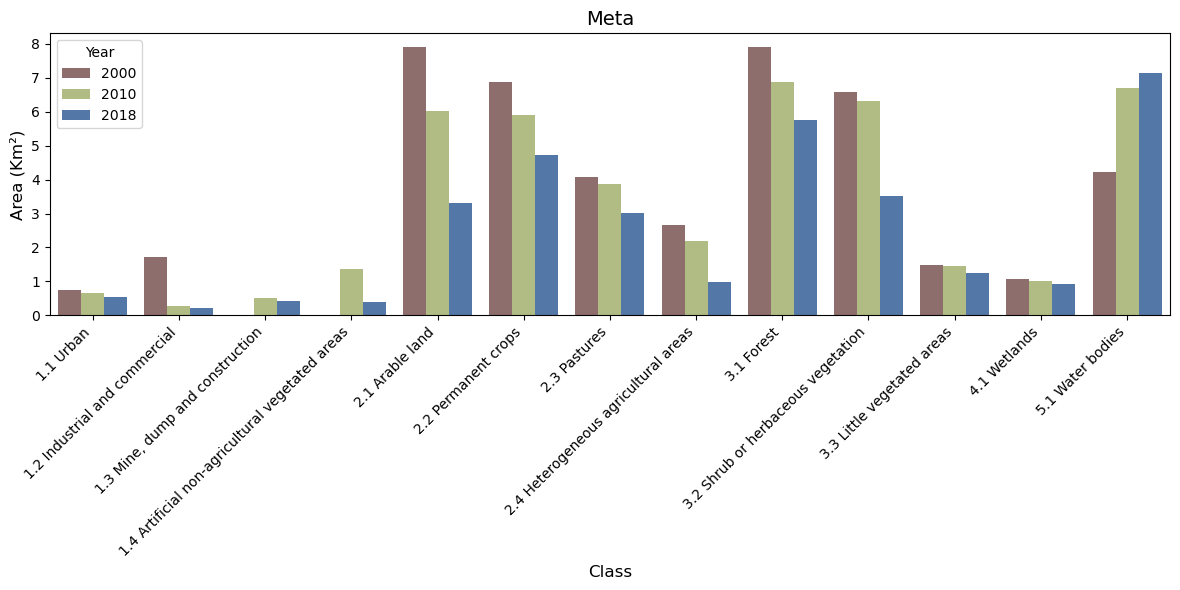

In [15]:
# Meta plot
plt.figure(figsize=(12, 6))
sns.barplot(
    data=meta_noclouds,
    x="level2",
    y="Area",
    hue="year",
    palette=["#946966", "#b6c57b", "#4575b4"],
    errorbar=None,
    order=sorted(meta_noclouds["level2"].unique())
)

# Style the plot
plt.title("Meta", fontsize=14)
plt.xlabel("Class", fontsize=12)
plt.ylabel("Area (Km²)", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title="Year")
plt.tight_layout()
plt.show()

In [16]:
ara_2000=ara_noclouds[ara_noclouds["year"]==2000]
ara_2010=ara_noclouds[ara_noclouds["year"]==2010]
ara_2018=ara_noclouds[ara_noclouds["year"]==2018]

casa_2000=casa_noclouds[casa_noclouds["year"]==2000]
casa_2010=casa_noclouds[casa_noclouds["year"]==2010]
casa_2018=casa_noclouds[casa_noclouds["year"]==2018]

meta_2000=meta_noclouds[meta_noclouds["year"]==2000]
meta_2010=meta_noclouds[meta_noclouds["year"]==2010]
meta_2018=meta_noclouds[meta_noclouds["year"]==2018]

In [17]:
ara_2000 = ara_2000.groupby("level2")["Area"].sum().reset_index()
ara_2010 = ara_2010.groupby("level2")["Area"].sum().reset_index()
ara_2018 = ara_2018.groupby("level2")["Area"].sum().reset_index()

casa_2000 = casa_2000.groupby("level2")["Area"].sum().reset_index()
casa_2010 = casa_2010.groupby("level2")["Area"].sum().reset_index()
casa_2018 = casa_2018.groupby("level2")["Area"].sum().reset_index()

meta_2000 = meta_2000.groupby("level2")["Area"].sum().reset_index()
meta_2010 = meta_2010.groupby("level2")["Area"].sum().reset_index()
meta_2018 = meta_2018.groupby("level2")["Area"].sum().reset_index()

In [35]:
meta_2018

,level2,Area
0,1.1 Urban,132.369452
1,1.2 Industrial and commercial,25.719259
2,"1.3 Mine, dump and construction",31.671407
3,1.4 Artificial non-agricultural vegetated areas,14.929477
4,2.1 Arable land,994.657056
5,2.2 Permanent crops,2194.577671
6,2.3 Pastures,16260.722430
7,2.4 Heterogeneous agricultural areas,6539.003119
8,3.1 Forest,32765.864086
9,3.2 Shrub or herbaceous vegetation,24287.850206


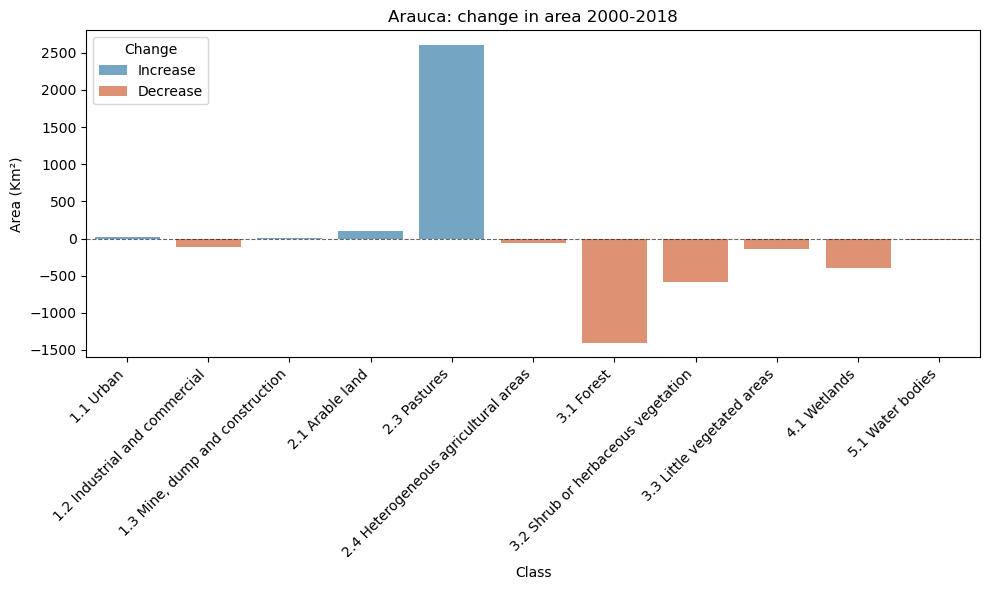

In [25]:
ara_2000_2018 = pd.merge(ara_2000, ara_2018, on="level2", suffixes=('_2000', '_2018'))
ara_2000_2018["diff"] = ara_2000_2018["Area_2018"] - ara_2000_2018["Area_2000"]
ara_2000_2018["Change"] = ara_2000_2018["diff"].apply(lambda x: "Increase" if x > 0 else "Decrease")

plt.figure(figsize=(10, 6))
sns.barplot(data=ara_2000_2018,
            x="level2", 
            y="diff", 
            hue="Change", 
            palette=["#67a9cf", "#ef8a62"], 
            dodge=False,
            errorbar=None,
            order=sorted(ara_2000_2018["level2"].unique()))
plt.axhline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
plt.xlabel("Class")
plt.ylabel("Area (Km²)")
plt.title("Arauca: change in area 2000-2018")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Change", loc="upper left")
plt.tight_layout()

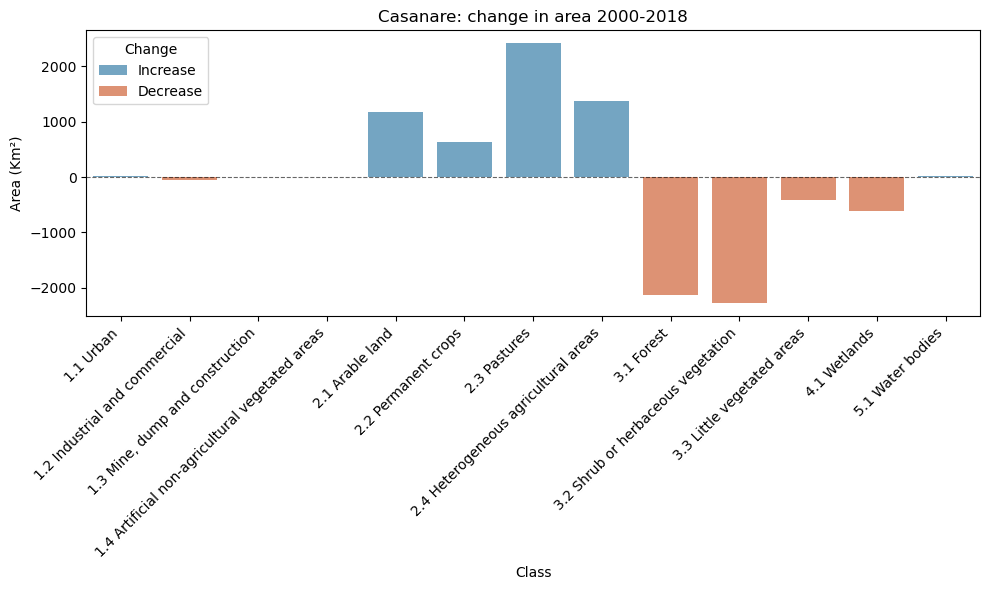

In [24]:
casa_2000_2018 = pd.merge(casa_2000, casa_2018, on="level2", suffixes=('_2000', '_2018'))
casa_2000_2018["diff"] = casa_2000_2018["Area_2018"] - casa_2000_2018["Area_2000"]
casa_2000_2018["Change"] = casa_2000_2018["diff"].apply(lambda x: "Increase" if x > 0 else "Decrease")

plt.figure(figsize=(10, 6))
sns.barplot(data=casa_2000_2018,
            x="level2", 
            y="diff", 
            hue="Change", 
            palette=["#67a9cf", "#ef8a62"], 
            dodge=False,
            errorbar=None,
            order=sorted(casa_2000_2018["level2"].unique()))
plt.axhline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
plt.xlabel("Class")
plt.ylabel("Area (Km²)")
plt.title("Casanare: change in area 2000-2018")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Change", loc="upper left")
plt.tight_layout()

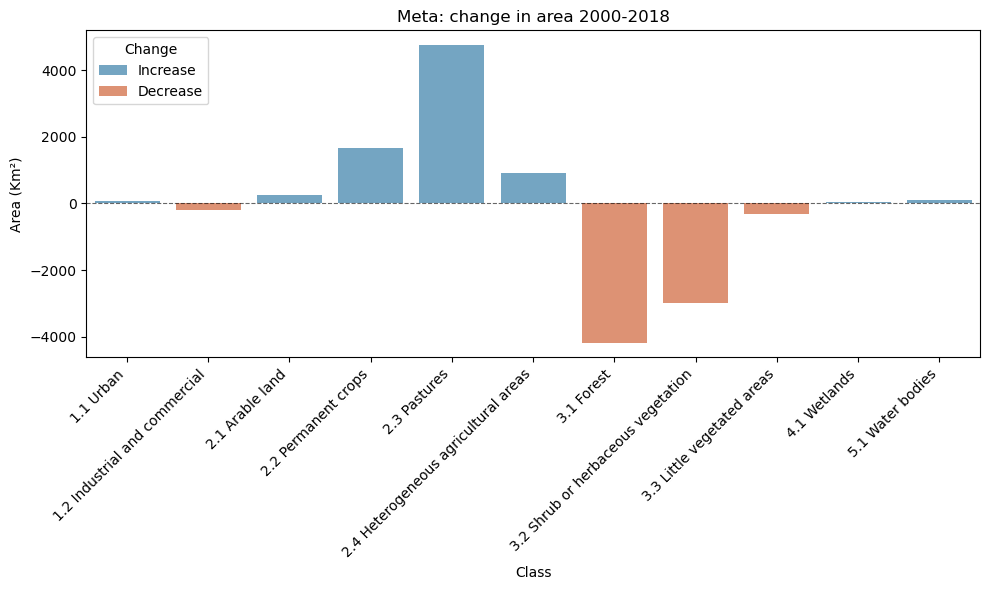

In [23]:
meta_2000_2018 = pd.merge(meta_2000, meta_2018, on="level2", suffixes=('_2000', '_2018'))
meta_2000_2018["diff"] = meta_2000_2018["Area_2018"] - meta_2000_2018["Area_2000"]
meta_2000_2018["Change"] = meta_2000_2018["diff"].apply(lambda x: "Increase" if x > 0 else "Decrease")

plt.figure(figsize=(10, 6))
sns.barplot(data=meta_2000_2018,
            x="level2", 
            y="diff", 
            hue="Change", 
            palette=["#67a9cf", "#ef8a62"], 
            dodge=False,
            errorbar=None,
            order=sorted(meta_2000_2018["level2"].unique()))
plt.axhline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
plt.xlabel("Class")
plt.ylabel("Area (Km²)")
plt.title("Meta: change in area 2000-2018")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Change", loc="upper left")
plt.tight_layout()

### Merge 3 departments

In [36]:
# Merge by year
lc_2000 = pd.concat([lc['ara_cover2000l2.gpkg'], lc['casa_cover2000l2.gpkg'], lc['meta_cover2000l2.gpkg']], ignore_index=True)
lc_2010 = pd.concat([lc['ara_cover2010l2.gpkg'], lc['casa_cover2010l2.gpkg'], lc['meta_cover2010l2.gpkg']], ignore_index=True)
lc_2018 = pd.concat([lc['ara_cover2018l2.gpkg'], lc['casa_cover2018l2.gpkg'], lc['meta_cover2018l2.gpkg']], ignore_index=True)

In [37]:
# Calculate area in square kilometers and aggregate by 'level2'
lc_2000["Area"] = lc_2000.geometry.area / 1e6
lc_2000_area = lc_2000.groupby("level2")["Area"].sum().reset_index()

lc_2010["Area"] = lc_2010.geometry.area / 1e6
lc_2010_area = lc_2010.groupby("level2")["Area"].sum().reset_index()

lc_2018["Area"] = lc_2018.geometry.area / 1e6
lc_2018_area = lc_2018.groupby("level2")["Area"].sum().reset_index()

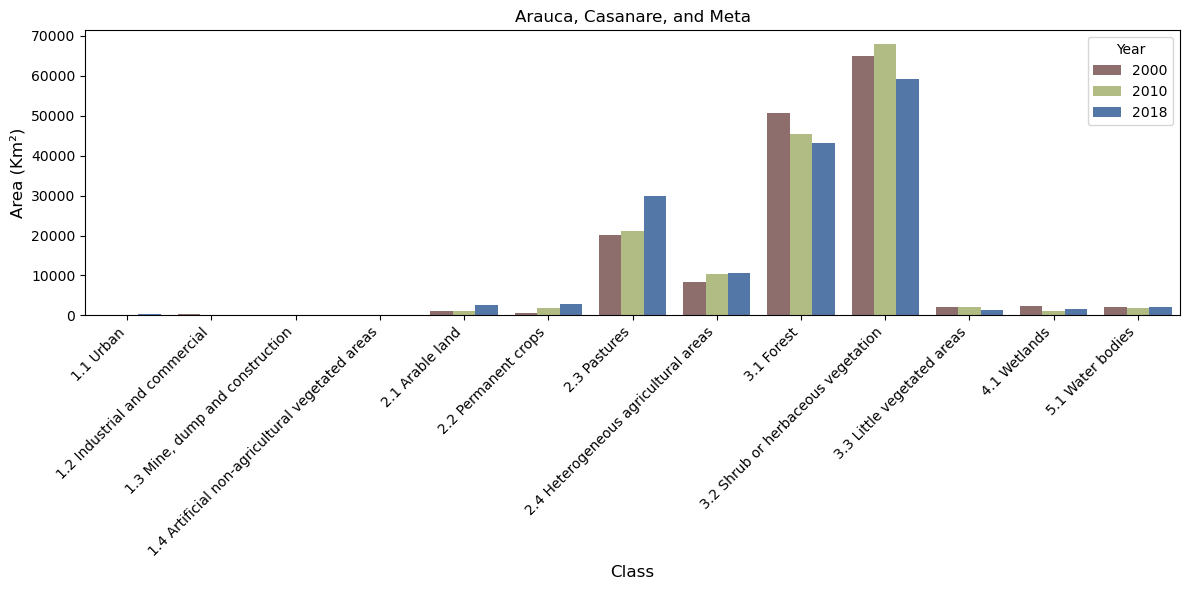

In [45]:
# Add 'Year' column to each dataframe
lc_2000_area["Year"] = 2000
lc_2010_area["Year"] = 2010
lc_2018_area["Year"] = 2018

# Combine all years into one dataframe
lc_all = pd.concat([lc_2000_area, lc_2010_area, lc_2018_area], ignore_index=True)

lc_all_noclouds = lc_all[lc_all["level2"] != "9.9 Unknown"]

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(
    data=lc_all_noclouds,
    x="level2",
    y="Area",
    hue="Year",
    palette=["#946966", "#b6c57b", "#4575b4"] 
)

# Style the plot
plt.xlabel("Class", fontsize=12)
plt.ylabel("Area (Km²)", fontsize=12)
plt.title("Arauca, Casanare, and Meta")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Year")
plt.tight_layout()
plt.show()

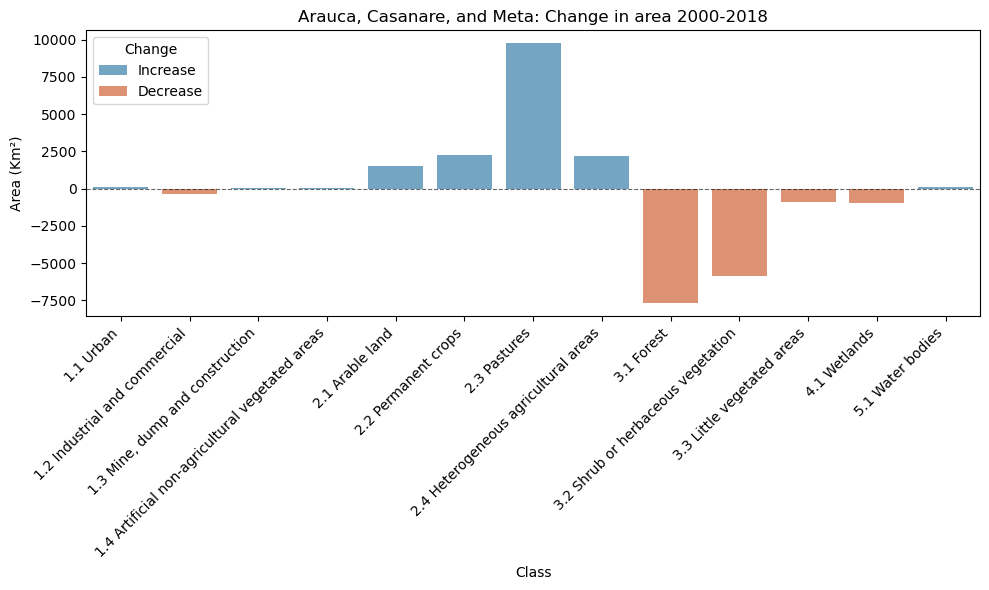

In [54]:
lc_2000_2018 = pd.merge(lc_2000_area, lc_2018_area, on="level2", suffixes=('_2000', '_2018'))
lc_2000_2018 = lc_2000_2018[lc_2000_2018["level2"] != "9.9 Unknown"]
lc_2000_2018["diff"] = lc_2000_2018["Area_2018"] - lc_2000_2018["Area_2000"]
lc_2000_2018["Change"] = lc_2000_2018["diff"].apply(lambda x: "Increase" if x > 0 else "Decrease")  

plt.figure(figsize=(10, 6))
sns.barplot(x="level2", y="diff", data=lc_2000_2018, hue="Change", palette=["#67a9cf", "#ef8a62"], dodge=False)
plt.axhline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
plt.xlabel("Class")
plt.ylabel("Area (Km²)")
plt.title("Arauca, Casanare, and Meta: Change in area 2000-2018")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Change", loc="upper left")
plt.tight_layout()

### Buffer

Water bodies

In [ ]:
BUFFER_METERS = 1000
out_dir = "./cover/buffers"
os.makedirs(out_dir, exist_ok=True)

def make_water_buffers(gdf, year):
    if "level2" not in gdf.columns:
        raise KeyError("level2 column not found")
    g = gdf.copy()
    # ensure valid geometries
    try:
        g["geometry"] = g.geometry.buffer(0)
    except Exception:
        pass
    # select water bodies (exact label "5.1 Water bodies")
    water = g[g["level2"].astype(str).str.strip() == "5.1 Water bodies"].copy()
    if water.empty:
        print(f"No water bodies found for {year}")
        return gpd.GeoDataFrame(columns=g.columns, crs=g.crs), gpd.GeoDataFrame(columns=["geometry"], crs=g.crs)
    # per-feature buffers
    water["geometry"] = water.geometry.buffer(BUFFER_METERS)
    water_buf = water.reset_index(drop=True)
    # dissolved buffer (single geometry)
    dissolved = gpd.GeoSeries([water_buf.unary_union]).set_crs(g.crs)
    dissolved_gdf = gpd.GeoDataFrame({"year":[int(year)]}, geometry=dissolved, crs=g.crs)
    # optional: save outputs
    water_buf.to_file(os.path.join(out_dir, f"waterbuffer_individual_{year}.gpkg"), driver="GPKG", layer=f"waterbuffer_individual_{year}")
    dissolved_gdf.to_file(os.path.join(out_dir, f"waterbuffer_dissolved_{year}.gpkg"), driver="GPKG", layer=f"waterbuffer_dissolved_{year}")
    print(f"Saved buffers for {year} → {out_dir}")
    return water_buf, dissolved_gdf

# create buffers for each year (results assigned to variables)
waterbuf_2000, waterbuf_2000_dissolved = make_water_buffers(lc_2000, "2000")
waterbuf_2010, waterbuf_2010_dissolved = make_water_buffers(lc_2010, "2010")
waterbuf_2018, waterbuf_2018_dissolved = make_water_buffers(lc_2018, "2018")

Saved buffers for 2000 → ./cover/buffers
Saved buffers for 2010 → ./cover/buffers
Saved buffers for 2018 → ./cover/buffers


### Sankey plot

In [9]:
inter=gpd.overlay(lc_2000,lc_2010,how='intersection')
if inter.crs.is_geographic:
    inter = inter.to_crs(epsg=3116)
inter['area']=inter.geometry.area/1e6

c:\Users\VICTUS\anaconda3\envs\osgeo-env-v1\lib\site-packages\ipykernel_launcher.py:1: UserWarning: `keep_geom_type=True` in overlay resulted in 840208 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  """Entry point for launching an IPython kernel.


In [11]:
inter = inter.rename(columns={'level2_1': 'Date1','level2_2':'Date2'})

label_set = set()
links = []

def add_links(inter, col_from, col_to):
    temp = inter.groupby([col_from, col_to])["area"].sum().reset_index()
    for _, row in temp.iterrows():
        source = f"{col_from}_{row[col_from]}"
        target = f"{col_to}_{row[col_to]}"
        value = row["area"]
        label_set.update([source, target])
        links.append((source, target, value))

add_links(inter, "Date1", "Date2")

# Asignar índices
labels = list(label_set)
label_to_index = {label: i for i, label in enumerate(labels)}

source = [label_to_index[s] for s, t, v in links]
target = [label_to_index[t] for s, t, v in links]
value = [v for s, t, v in links]

# Diccionario de colores
color_dict = {
    "1.1 Urban": "#761800",
    "1.2 Industrial and commercial": "#934741",
    "1.3 Mine, dump and construction": "#4616d4",
    "1.4 Artificial non-agricultural vegetated areas": "#A600CC",
    "2.1 Arable land": "#e8d610",
    "2.2 Permanent crops": "#F2CCAA",
    "2.3 Pastures": "#cddc97",
    "2.4 Heterogeneous agricultural areas": "#9BCA3E",
    "3.1 Forest": "#3a6a00",
    "3.2 Shrub or herbaceous vegetation": "#cafb4d",
    "3.3 Little vegetated areas": "#bfc5b9",
    "4.1 Wetlands": "#6b5c8c",
    "5.1 Water bodies": "#0127ff",
    "9.9 Unknown": "#808080"
}

display_labels = [label.split("_", 1)[1] for label in labels]

# Colores para los nodos
colors = []
for label in labels:
    class_name = label.split("_", 1)[1].strip()
    colors.append(color_dict.get(class_name, "gray"))

def hex_to_rgba(hex_color, alpha=0.6):
    hex_color = hex_color.lstrip("#")
    r, g, b = tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))
    return f"rgba({r},{g},{b},{alpha})"

missing_classes = set()
for s, t, v in links:
    class_name = s.split("_", 1)[1].strip()
    if class_name not in color_dict:
        missing_classes.add(class_name)

link_colors = []
for s, t, v in links:
    class_name = s.split("_", 1)[1].strip()
    hex_color = color_dict.get(class_name, "#999999")
    link_colors.append(hex_to_rgba(hex_color))

# Crear el Sankey plot
fig = go.Figure(data=[go.Sankey(
    arrangement="snap",
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=display_labels,
        color=colors
    ),
    link=dict(
        source=source,
        target=target,
        value=value,
        color=link_colors
    )
)])

fig.update_layout(
    title_text="Sankey plot 2000 and 2010",
    font_size=12
)

In [12]:
inter2=gpd.overlay(lc_2010,lc_2018,how='intersection')
if inter2.crs.is_geographic:
    inter2 = inter2.to_crs(epsg=3116)
inter2['area']=inter2.geometry.area/1e6

c:\Users\VICTUS\anaconda3\envs\osgeo-env-v1\lib\site-packages\ipykernel_launcher.py:1: UserWarning:

`keep_geom_type=True` in overlay resulted in 496781 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries



In [13]:
inter2 = inter2.rename(columns={'level2_1': 'Date1','level2_2':'Date2'})

label_set = set()
links = []

def add_links(inter2, col_from, col_to):
    temp = inter2.groupby([col_from, col_to])["area"].sum().reset_index()
    for _, row in temp.iterrows():
        source = f"{col_from}_{row[col_from]}"
        target = f"{col_to}_{row[col_to]}"
        value = row["area"]
        label_set.update([source, target])
        links.append((source, target, value))

add_links(inter2, "Date1", "Date2")

# Asignar índices
labels = list(label_set)
label_to_index = {label: i for i, label in enumerate(labels)}

source = [label_to_index[s] for s, t, v in links]
target = [label_to_index[t] for s, t, v in links]
value = [v for s, t, v in links]

# Diccionario de colores
color_dict = {
    "1.1 Urban": "#761800",
    "1.2 Industrial and commercial": "#934741",
    "1.3 Mine, dump and construction": "#4616d4",
    "1.4 Artificial non-agricultural vegetated areas": "#A600CC",
    "2.1 Arable land": "#e8d610",
    "2.2 Permanent crops": "#F2CCAA",
    "2.3 Pastures": "#cddc97",
    "2.4 Heterogeneous agricultural areas": "#9BCA3E",
    "3.1 Forest": "#3a6a00",
    "3.2 Shrub or herbaceous vegetation": "#cafb4d",
    "3.3 Little vegetated areas": "#bfc5b9",
    "4.1 Wetlands": "#6b5c8c",
    "5.1 Water bodies": "#0127ff",
    "9.9 Unknown": "#808080"
}

display_labels = [label.split("_", 1)[1] for label in labels]

# Colores para los nodos
colors = []
for label in labels:
    class_name = label.split("_", 1)[1].strip()
    colors.append(color_dict.get(class_name, "gray"))

def hex_to_rgba(hex_color, alpha=0.6):
    hex_color = hex_color.lstrip("#")
    r, g, b = tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))
    return f"rgba({r},{g},{b},{alpha})"

missing_classes = set()
for s, t, v in links:
    class_name = s.split("_", 1)[1].strip()
    if class_name not in color_dict:
        missing_classes.add(class_name)

link_colors = []
for s, t, v in links:
    class_name = s.split("_", 1)[1].strip()
    hex_color = color_dict.get(class_name, "#999999")
    link_colors.append(hex_to_rgba(hex_color))

# Crear el Sankey plot
fig = go.Figure(data=[go.Sankey(
    arrangement="snap",
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=display_labels,
        color=colors
    ),
    link=dict(
        source=source,
        target=target,
        value=value,
        color=link_colors
    )
)])

fig.update_layout(
    title_text="Sankey plot 2010 and 2018",
    font_size=12
)

In [14]:
inter3=gpd.overlay(lc_2000,lc_2018,how='intersection')
if inter3.crs.is_geographic:
    inter3 = inter3.to_crs(epsg=3116)
inter3['area']=inter3.geometry.area/1e6

c:\Users\VICTUS\anaconda3\envs\osgeo-env-v1\lib\site-packages\ipykernel_launcher.py:1: UserWarning:

`keep_geom_type=True` in overlay resulted in 436544 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries



In [16]:
inter3 = inter3.rename(columns={'level2_1': 'Date1','level2_2':'Date2'})

label_set = set()
links = []

def add_links(inter3, col_from, col_to):
    temp = inter3.groupby([col_from, col_to])["area"].sum().reset_index()
    for _, row in temp.iterrows():
        source = f"{col_from}_{row[col_from]}"
        target = f"{col_to}_{row[col_to]}"
        value = row["area"]
        label_set.update([source, target])
        links.append((source, target, value))

add_links(inter3, "Date1", "Date2")

# Asignar índices
labels = list(label_set)
label_to_index = {label: i for i, label in enumerate(labels)}

source = [label_to_index[s] for s, t, v in links]
target = [label_to_index[t] for s, t, v in links]
value = [v for s, t, v in links]

# Diccionario de colores
color_dict = {
    "1.1 Urban": "#761800",
    "1.2 Industrial and commercial": "#934741",
    "1.3 Mine, dump and construction": "#4616d4",
    "1.4 Artificial non-agricultural vegetated areas": "#A600CC",
    "2.1 Arable land": "#e8d610",
    "2.2 Permanent crops": "#F2CCAA",
    "2.3 Pastures": "#cddc97",
    "2.4 Heterogeneous agricultural areas": "#9BCA3E",
    "3.1 Forest": "#3a6a00",
    "3.2 Shrub or herbaceous vegetation": "#cafb4d",
    "3.3 Little vegetated areas": "#bfc5b9",
    "4.1 Wetlands": "#6b5c8c",
    "5.1 Water bodies": "#0127ff",
    "9.9 Unknown": "#808080"
}

display_labels = [label.split("_", 1)[1] for label in labels]

# Colores para los nodos
colors = []
for label in labels:
    class_name = label.split("_", 1)[1].strip()
    colors.append(color_dict.get(class_name, "gray"))

def hex_to_rgba(hex_color, alpha=0.6):
    hex_color = hex_color.lstrip("#")
    r, g, b = tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))
    return f"rgba({r},{g},{b},{alpha})"

missing_classes = set()
for s, t, v in links:
    class_name = s.split("_", 1)[1].strip()
    if class_name not in color_dict:
        missing_classes.add(class_name)

link_colors = []
for s, t, v in links:
    class_name = s.split("_", 1)[1].strip()
    hex_color = color_dict.get(class_name, "#999999")
    link_colors.append(hex_to_rgba(hex_color))

# Crear el Sankey plot
fig = go.Figure(data=[go.Sankey(
    arrangement="snap",
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=display_labels,
        color=colors
    ),
    link=dict(
        source=source,
        target=target,
        value=value,
        color=link_colors
    )
)])

fig.update_layout(
    title_text="Sankey plot 2000 and 2018",
    font_size=12
)